# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 67     |  |
| :-------------|:-------------|
| Hidde van den Bergh| 6576079 |
| Annet Moeleker| 6300316 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

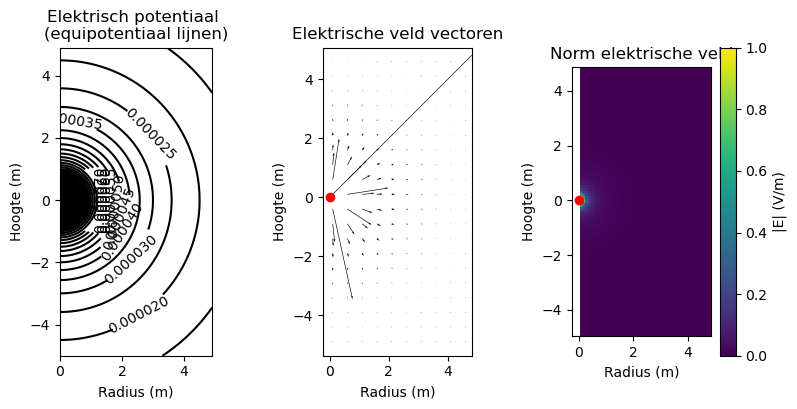

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De z-waarde die het dichtst bij 0 ligt is: -1.7763568394002505e-14 en heeft index 50
De fitfunctie heeft als exponent -1.0
De theoretische waarde van a is: 8.987742437988218e-05 en b is: -1


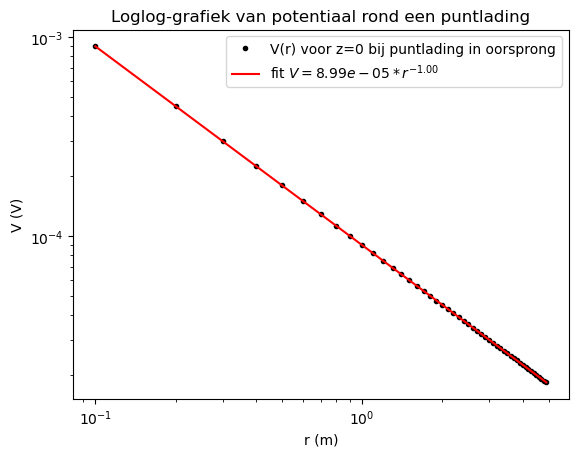

In [3]:
#opdracht 1
afstand=np.abs(z) #absolute afstand tot z=0
index_z0 = np.argmin(afstand) #geeft de index van de z-waarde die het dichtst bij z=0 ligt
print('De z-waarde die het dichtst bij 0 ligt is:', z[index_z0], 'en heeft index', index_z0)

#opdracht 2
V_z0 = V[index_z0, :] #slice waardes voor z=0 voor V
#slice waardes voor r en V, want log(0) is niet gedefinieerd
r_slice = r[1:] 
V_z0 = V_z0[1:] 

#loglog grafiek 
plt.figure()
plt.title('Loglog-grafiek van potentiaal rond een puntlading')
plt.xlabel('r (m)')
plt.ylabel('V (V)')
plt.loglog(r_slice,V_z0,'k.',label='V(r) voor z=0 bij puntlading in oorsprong')


#opdracht 3
from scipy.optimize import curve_fit
#machtsfunctie om te fitten: log(V) = log(c) + b*log(r) = a + b*log(r) => V = a * r^b
def functiefit1_V(r,a,b):
    return a+b*np.log(r)
val,cov = curve_fit(functiefit1_V, r_slice, np.log(V_z0), maxfev=10000)
#plot de loglog grafiek van de fitfunctie
plt.loglog(r_slice, np.exp(functiefit1_V(r_slice,*val)), 'r-', label = r'fit $V={:.2e} * r^{{{:.2f}}}$'.format(np.exp(val[0]), val[1]))
plt.legend()


#opdracht 4
print('De fitfunctie heeft als exponent', round(val[1],3))
#Potentiaal voor puntlading: V(r)=q/(4πε0*r) 
print('De theoretische waarde van a is:', charge_one_point/(4*np.pi*epsilon0), 'en b is:', -1)

plt.show()
    

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

De z-waarde die het dichtst bij 0 ligt is: -1.7763568394002505e-14 en heeft index 49
De fitfunctie heeft als exponent -2.04
De theoretische waarde van a is: 8.987742437988218e-05 en b is: -2


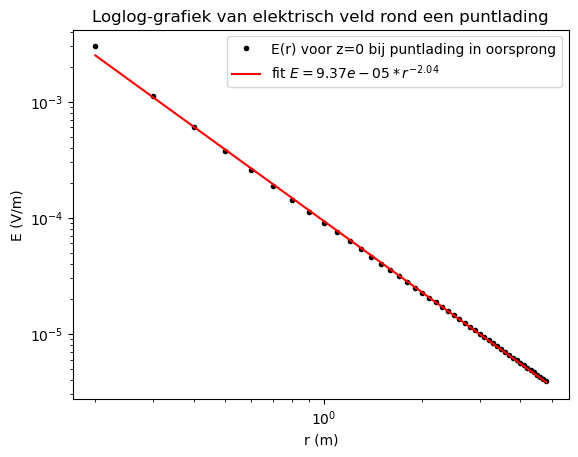

In [4]:
#opdracht 2
#door de finite difference method zijn de shapes van de arrays voor E nu anders
#opnieuw bepalen welke z-waarde het dichtst bij 0 ligt, maar nu voor de arrays van E
afstand=np.abs(z_for_E) #absolute afstand tot z=0
index_z0_for_E = np.argmin(afstand) #geeft de index van de z-waarde die het dichtst bij z=0 ligt
print('De z-waarde die het dichtst bij 0 ligt is:', z_for_E[index_z0_for_E], 'en heeft index', index_z0_for_E)

E_z0 = normE[index_z0_for_E, :] #slice waardes voor z=0 voor E

#slice waardes voor r en E, want log(0) is niet gedefinieerd
r_slice_E = r_for_E[1:] 
E_z0 = E_z0[1:] 

#loglog grafiek 
plt.figure()
plt.title('Loglog-grafiek van elektrisch veld rond een puntlading')
plt.xlabel('r (m)')
plt.ylabel('E (V/m)')
plt.loglog(r_slice_E,E_z0,'k.',label='E(r) voor z=0 bij puntlading in oorsprong')

#opdracht 3
#machtsfunctie om te fitten
def functiefit1_E(r,a,b):
    return a+b*np.log(r)
val,cov = curve_fit(functiefit1_E, r_slice_E, np.log(E_z0),maxfev=10000)
#plot de loglog grafiek van de fitfunctie
plt.loglog(r_slice_E, np.exp(functiefit1_E(r_slice_E,*val)), 'r-', label = r'fit $E={:.2e} * r^{{{:.2f}}}$'.format(np.exp(val[0]), val[1]))
plt.legend()


#opdracht 4
print('De fitfunctie heeft als exponent', round(val[1],3))
#E=q/(4πε0*r^2)
print('De theoretische waarde van a is:', charge_one_point/(4*np.pi*epsilon0), 'en b is:', -2)

plt.show()


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

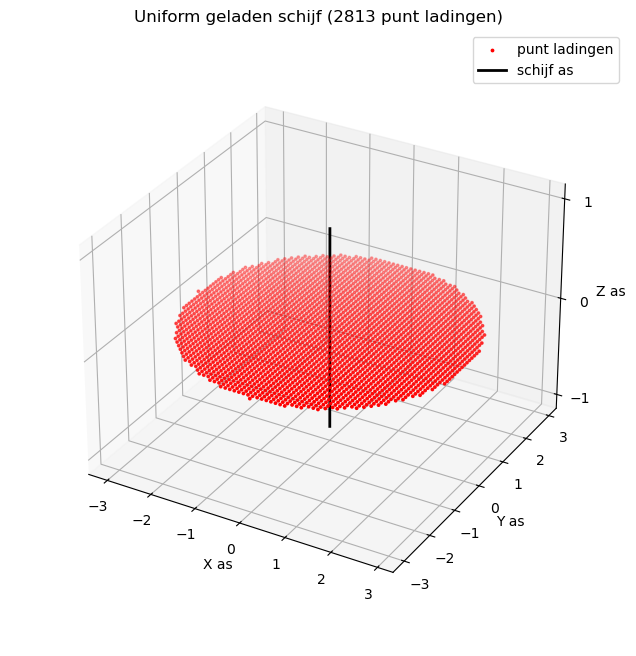

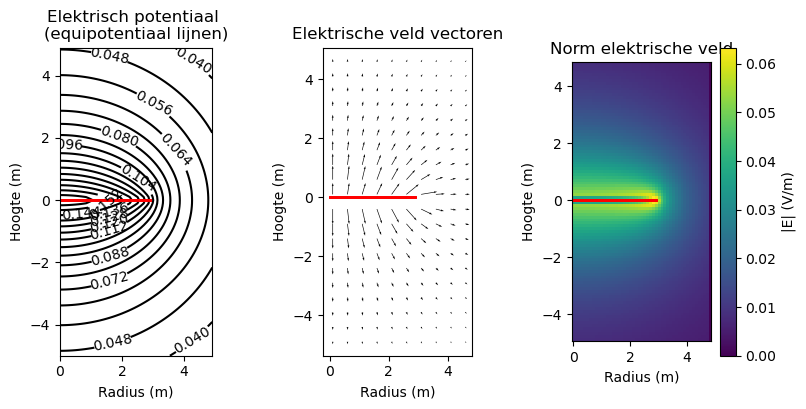

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius variabele is de straal van de schijf bestaande uit puntladingen. Als de disk radius naar 0 gaat zal de schijf een puntlading worden. 
2. De gridstep bepaald wat de afstand is tussen de individuele puntladingen die gezamenlijk een schijf vormen. Als de gridstep kleiner wordt gemaakt, moeten er meer puntladingen worden gesimuleerd en duurt het uitvoeren van de simulatie langer.
3. De variabele z_coord_DISK geeft de hoogte op de z-as van de schijf in de onderste drie plots. De bovenste plot verandert niet. Door deze variabele aan te passen en de idx_z_zero niet te veranderen, wordt de potentiaal en het elektrische veld berekend op een hoogte z=0, maar wordt de schijf in de onderste drie plots op een andere hoogte geplaatst.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
# σ = Q_tot / A
sigma = (number_point_charges_on_disk * charge_one_point) / (np.pi * disk_radius**2)
print(f'De ladingsdichtheid van de schijf is {sigma:.1e} C/m^2')

De ladingsdichtheid van de schijf is 9.9e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

De z-waarde die het dichtst bij 0 ligt is: -1.7763568394002505e-14 en heeft index 50


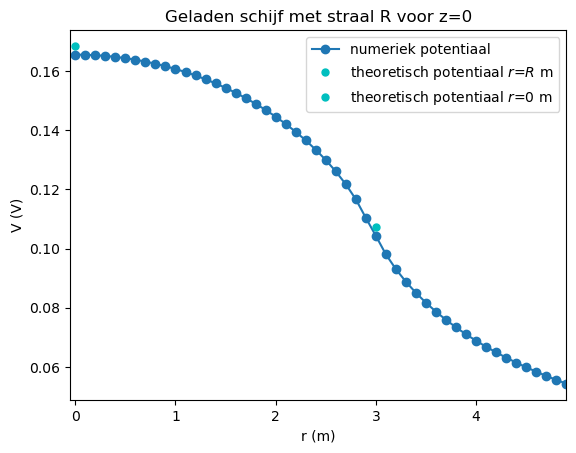

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
#waarde voor z=0 bepalen uit z-array
afstand=np.abs(z) #absolute afstand tot z=0
idx_z_zero = np.argmin(afstand) #geeft de index van de z-waarde die het dichtst bij z=0 ligt
print('De z-waarde die het dichtst bij 0 ligt is:', z[idx_z_zero], 'en heeft index', idx_z_zero)

#opdracht 1
V_z0 = V[idx_z_zero, :] #array voor elektrisch potentiaal op z=0 voor verschillende r

#opdracht 2
V_R = (sigma*disk_radius)/(np.pi*epsilon0) # potentiaal op de straal van de schijf
r_R = disk_radius  # straal van de schijf

#opdracht 3
V_0 = (sigma*disk_radius)/(2*epsilon0) # potentiaal op r = 0

#grafiek
plt.figure()
plt.title(f"Geladen schijf met straal R voor z=0")
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.xlim(-0.05,max(r))
plt.ylim(0.9*min(V_z0),1.05*max(V_z0))
plt.plot(r, V_z0, "o-", label="numeriek potentiaal")                                #opdracht 1
plt.plot(r_R, V_R, "c.", markersize=10, label="theoretisch potentiaal $r$=$R$ m")   #opdracht 2
plt.plot(0, V_0, "c.", markersize=10, label="theoretisch potentiaal $r$=0 m")       #opdracht 3
plt.legend()
plt.show()

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


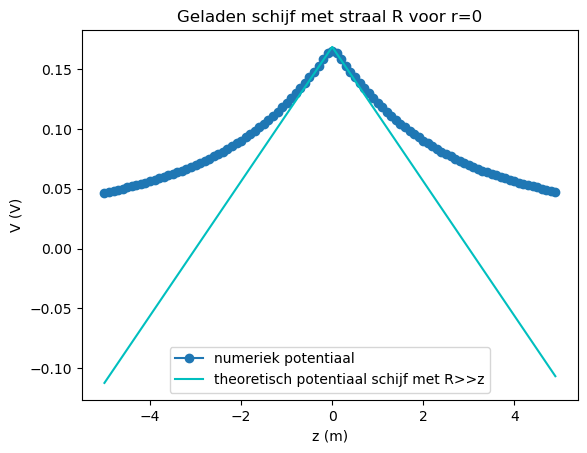

In [9]:
#opdracht 1
V_r0 = V[:,0] #array voor elektrisch potentiaal op r=0 voor verschillende z
#opdracht 2
V_r0_R = (sigma/(2*epsilon0)) * (disk_radius-np.abs(z))

#grafiek
plt.figure()
plt.title(f"Geladen schijf met straal R voor r=0")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.plot(z, V_r0, "o-", label="numeriek potentiaal")        #opdracht 1
plt.plot(z, V_r0_R, "c-", label="theoretisch potentiaal schijf met R>>z")   #opdracht 2
plt.legend()
plt.savefig('figures/2d_potentiaal_schijf_r0.png')         #opdracht 3
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

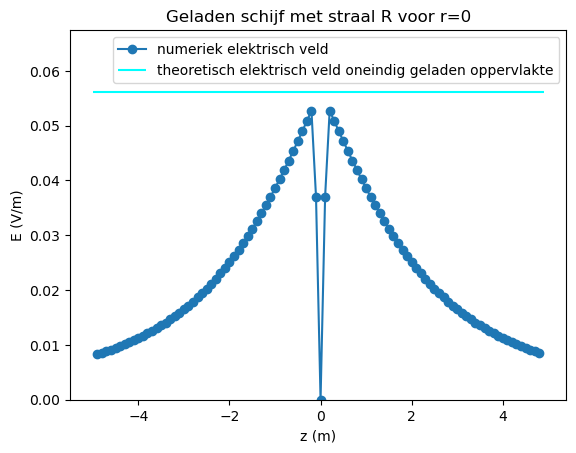

In [10]:
#opdracht 1
normE_r0 = normE[:,0] #array voor norm van elektrisch veld op r=0 voor verschillende z
#opdracht 2
E_r0 = (sigma/(2*epsilon0))

#grafiek
plt.figure()
plt.title(f"Geladen schijf met straal R voor r=0")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.ylim(0,E_r0*1.2)
plt.plot(z_for_E, normE_r0, "o-", label="numeriek elektrisch veld") #opdracht 1
plt.hlines(E_r0, min(z), max(z), color='cyan',label="theoretisch elektrisch veld oneindig geladen oppervlakte") #opdracht 2
plt.legend()
plt.savefig('figures/2e_potentiaal_schijf_r0.png')  #opdracht 3
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f
1. Het elektrische veld van een uniform geladen schijf en van een oneindig geladen plaat benadert elkaar vlak boven of onder z=0. Voor waarden van z met z << R kan een oneindige plaat namelijk benadert worden door een schijf. Dit is ook te zien in de grafiek van hierboven. 
2. Voor grotere waardes van z neemt het elektrische veld van de schijf af, omdat de afstand tot het geladen object toeneemt. Op grotere afstand van de oneindig geladen plaat is er nog steeds hetzelfde elektrische veld, dus deze is constant. \
Daarnaast valt het ook op dat het elektrische veld voor z->0 naar 0 gaat voor de geladen schijf. Dit is omdat in het exacte midden van de schijf de bijdragen van alle ladings­elementen in het vlak elkaar opheffen in de z-richting. Voor elke puntlading in de positieve z-richting is er namelijk een puntlading in de negatieve z-richting. Dit is ook te zien aan de elektrische veld vectoren in de figuur boven vraag 2a. 


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

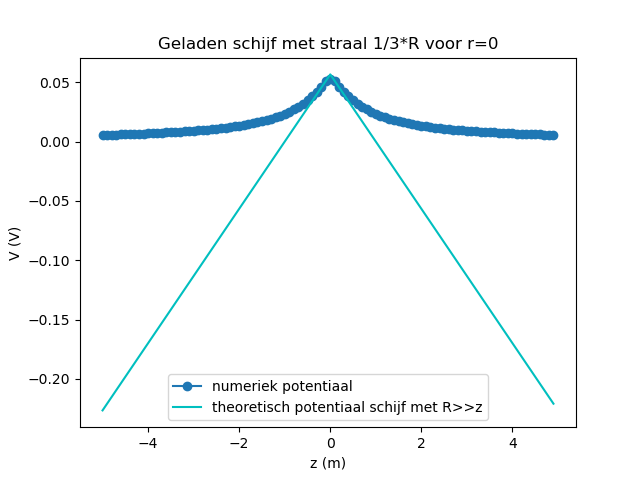

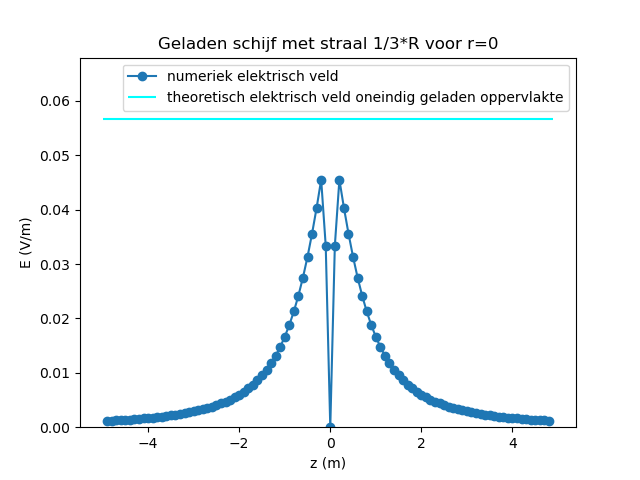

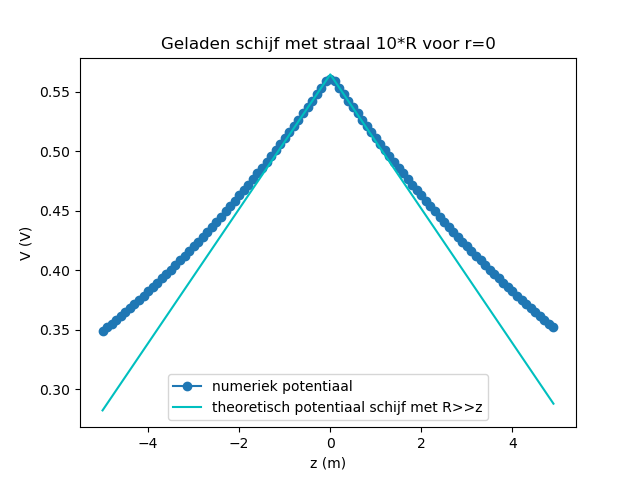

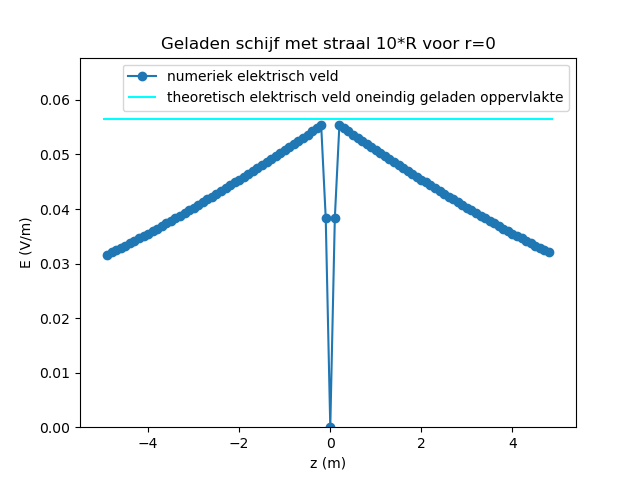

In [11]:
#straal 1/3R
display(Image("figures/2g1_potentiaal_schijf_r0.png", width=400))
display(Image("figures/2g2_potentiaal_schijf_r0.png", width=400))
#straal 10R
display(Image("figures/2g3_potentiaal_schijf_r0.png", width=400))
display(Image("figures/2g4_potentiaal_schijf_r0.png", width=400))

##### Antwoorden 2g

De geladen schijf met een 10 keer zo grote straal wordt beter benaderd door de theoretische potentiaal schijf met R>>z dan de originele schijf. \
De geladen schijf met een 3 keer zo kleine straal wordt minder goed benaderd door het theoretische oneindig geladen oppervlakte dan een grotere schijf. 

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Het elektrisch veld door een oneindig geladen plaat wordt gegeven door: $|E| = \sigma/(2 \epsilon_0)$. Als het elektrisch veld van de schijf 10% is in vergelijking met dat van een oneindig geladen plaat geeft dat de vergelijking: 
$$ \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] = 0.1*\frac{\sigma}{2\epsilon_0}$$
$$ \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] = 0.1 $$
$$ \frac{z}{\sqrt{R^2 + z^2}} = 0.9 $$
$$ \frac{z^2}{R^2 + z^2} = 0.81 $$
$$ z^2-0.81z^2=0.81R^2$$
$$z = \sqrt{\frac{0.81R^2}{0.19}} ≈ 2.06*R$$



### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

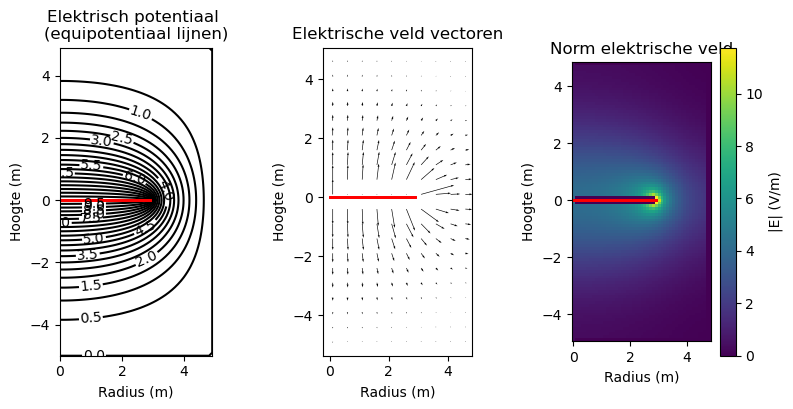

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

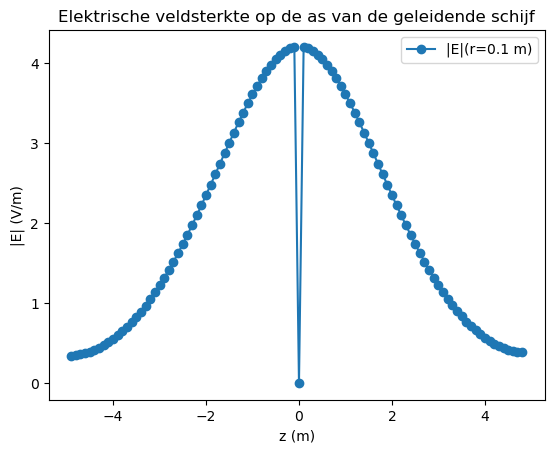

Elektrische veldnorm dicht bij het midden van de schijf
Dus voor r = 0.1 m (dichtst bij de as) en z=-1.8e-14 m (dichtst bij het midden) geldt:
  |E| = 0.015 mV/m


In [40]:
#3a

# opdracht 1
# Neem de as van de schijf als de r-waarde die het dichtst bij 0 ligt
# In de grafiek hierboven is te zien dat dit de minimale waarde van de r-array is
idx_r_axis = 0
E_on_axis = normE[:, idx_r_axis]

# grafiek van E op de as van de schijf
plt.figure()
plt.plot(z_for_E, E_on_axis, "o-", label=rf"|E|(r={r_for_E[idx_r_axis]} m)")
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.title("Elektrische veldsterkte op de as van de geleidende schijf")
plt.legend()
plt.show()

# opdracht 2
# Zoek punt het dichtst bij het midden van de schijf (z = 0)
idx_z_center = np.argmin(np.abs(z_for_E))
E_near_center = E_on_axis[idx_z_center]

print("Elektrische veldnorm dicht bij het midden van de schijf")
print('Dus voor r =', r_for_E[idx_r_axis],f'm (dichtst bij de as) en z={z_for_E[idx_z_center]:.1e} m (dichtst bij het midden) geldt:')
print(f"  |E| = {E_near_center*1000:.3f} mV/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

#### Antwoord 3b.1
Volgens Griffiths 2.3.5 geldt voor de grensvoorwaarden aan een geleidend oppervlakte:


$E_{\perp,\text{buiten}} - E_{\perp,\text{binnen}} = \frac{\sigma}{\varepsilon_0}$


Omdat in de geleider ($E_{\perp,\text{binnen}}=0$), krijg je in het midden (($r=0$), net buiten het oppervlak):


$\sigma(0) \approx \varepsilon_0\cdot E_{\perp}(0)$  ($\cdot$ wordt hier gebruikt als een normale vermenigvuldiging en niet als inproduct.)


Dus je kan de benadering nemen:


$\sigma(0) \approx \varepsilon_0\cdot|E_{\text{near center}}|$ ($\cdot$ wordt hier gebruikt als een normale vermenigvuldiging en niet als inproduct.)

In [14]:
#3b.2

# Gebruik E_near_center uit vraag 3a; bereken deze opnieuw als die variabele nog niet bestaat
if 'E_near_center' not in globals():
    idx_r_axis = np.argmin(np.abs(r_for_E))
    E_on_axis = normE[:, idx_r_axis]
    idx_z_center = np.argmin(np.abs(z_for_E))
    E_near_center = E_on_axis[idx_z_center]

# Benadering in het midden: sigma(0) ≈ epsilon0 * |E_near_center|
sigma_center = epsilon0 * np.abs(E_near_center)


print(f'  sigma(0) ≈ {sigma_center:.3e} C/m^2')

  sigma(0) ≈ 1.347e-16 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Resultaten vraag 3c:
  Totale lading geleidende schijf: Q = 7.618e-15 C
  Sigma(0) geleidende schijf:      1.347e-16 C/m^2
  Sigma uniform (zelfde Q):        2.694e-16 C/m^2
  Verhouding sigma(0)/sigma_uniform = 0.500


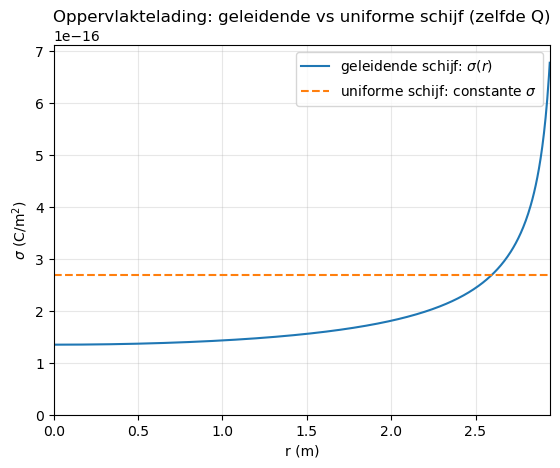

In [15]:
# 3c

# Zorg dat sigma_center beschikbaar is (uit vraag 3b.2)
if 'sigma_center' not in globals():
    if 'E_near_center' not in globals():
        idx_r_axis = np.argmin(np.abs(r_for_E))
        E_on_axis = normE[:, idx_r_axis]
        idx_z_center = np.argmin(np.abs(z_for_E))
        E_near_center = E_on_axis[idx_z_center]
    sigma_center = epsilon0 * np.abs(E_near_center)

R = disk_radius

# opdracht 1) Totale lading Q uit sigma(0) van geleidende schijf:
# sigma(0) = Q / (2*pi*R^2)  ->  Q = 2*pi*R^2*sigma(0)
Q_conducting = 2 * np.pi * R**2 * sigma_center

# opdracht 2) Vergelijk met uniforme schijf met dezelfde totale lading
sigma_uniform = Q_conducting / (np.pi * R**2)
sigma_center_conducting = sigma_center
ratio_center_to_uniform = sigma_center_conducting / sigma_uniform

print('Resultaten vraag 3c:')
print(f'  Totale lading geleidende schijf: Q = {Q_conducting:.3e} C') #opdracht 1
print(f'  Sigma(0) geleidende schijf:      {sigma_center_conducting:.3e} C/m^2') #opdracht 2
print(f'  Sigma uniform (zelfde Q):        {sigma_uniform:.3e} C/m^2') #opdracht 2
print(f'  Verhouding sigma(0)/sigma_uniform = {ratio_center_to_uniform:.3f}') #opdracht 2

# opdracht 3) & opdracht 4) Plot sigma(r) voor geleidende schijf en uniforme schijf
# Niet tot r=R plotten, omdat sigma(r) daar singular wordt
r_plot_max = 0.98 * R
r_plot = np.linspace(0, r_plot_max, 600)
sigma_conducting = Q_conducting / (2 * np.pi * R * np.sqrt(R**2 - r_plot**2))

plt.figure()
plt.plot(r_plot, sigma_conducting, label='geleidende schijf: $\\sigma(r)$')
plt.hlines(sigma_uniform, 0, r_plot_max, colors='tab:orange', linestyles='--',
           label='uniforme schijf: constante $\\sigma$')
plt.xlabel('r (m)')
plt.ylabel('$\\sigma$ (C/m$^2$)')
plt.title('Oppervlaktelading: geleidende vs uniforme schijf (zelfde Q)')
plt.xlim(0, r_plot_max)
plt.ylim(0, max(np.max(sigma_conducting) * 1.05, sigma_uniform * 1.2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# 3d 1 t/m 4

# Zorg dat E in het midden beschikbaar is
if 'E_near_center' not in globals():
    idx_r_axis = np.argmin(np.abs(r_for_E))
    E_on_axis = normE[:, idx_r_axis]
    idx_z_center = np.argmin(np.abs(z_for_E))
    E_near_center = E_on_axis[idx_z_center]

E_center = np.abs(E_near_center)

# opdracht 1) Maximum elektrisch veld in de simulatie
idx_max_flat = np.argmax(normE)
idx_z_max, idx_r_max = np.unravel_index(idx_max_flat, normE.shape)
E_max = normE[idx_z_max, idx_r_max]

# opdracht 2) Locatie van dit maximum
r_max = r_for_E[idx_r_max]
z_max = z_for_E[idx_z_max]

# opdracht 3) Hoeveel hoger dan E in het midden
ratio_max_to_center = E_max / E_center
delta_E = E_max - E_center

# opdracht 4) Netjes printen

print(f'  Maximum |E| in simulatie     : {E_max:.3e} V/m')
print(f'  Locatie van maximum          : r = {r_max:.3f} m, z = {z_max:.3f} m')
print(f'  |E| in midden van de schijf  : {E_center:.3e} V/m')
print(f'  Verschil Δ|E|                : {delta_E:.3e} V/m')


  Maximum |E| in simulatie     : 1.175e+01 V/m
  Locatie van maximum          : r = 3.000 m, z = 0.100 m
  |E| in midden van de schijf  : 1.521e-05 V/m
  Verschil Δ|E|                : 1.175e+01 V/m


##### Antwoord 3d.5

Het lokaal hoge elektrische veld bij de rand van de schijf wordt veroorzaakt door het edge effect.

Aan de rand is de kromming van het equipotentiaaloppervlak groter en kunnen veldlijnen minder gelijkmatig verdeeld blijven. Daardoor "dicht" het veld zich op aan de rand en wordt de veldsterkte daar veel groter dan in het midden.

Fysisch is dit te zien als ladingsophoping aan de randen van een geleider: om overal hetzelfde potentiaal te houden, verschuift meer lading naar de rand, en dat geeft lokaal een hoger elektrisch veld.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

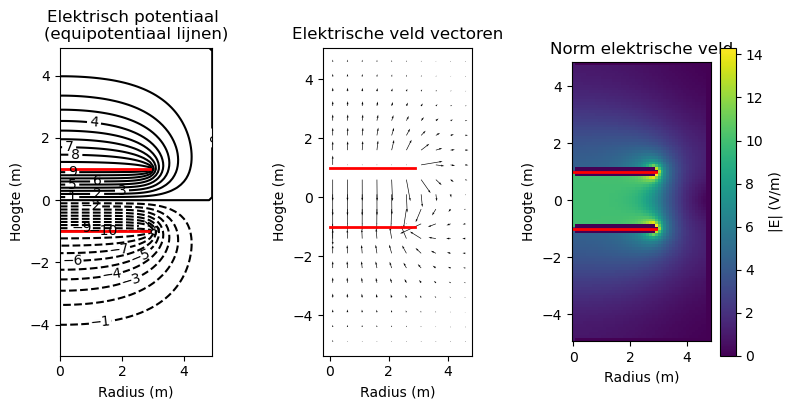

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


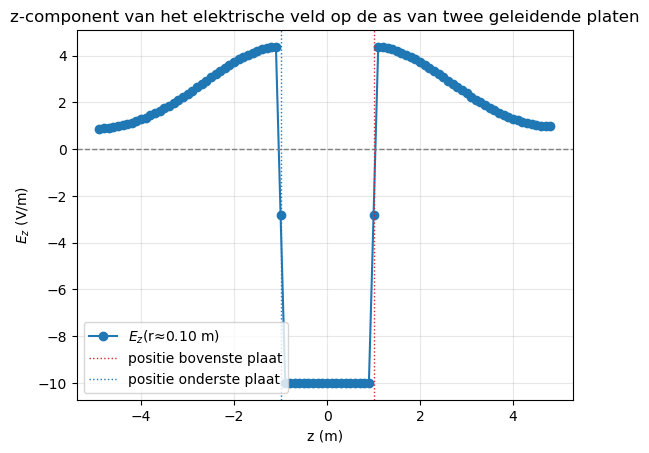

In [18]:
#4a
# Neem de as als de r-waarde die het dichtst bij 0 ligt
idx_r_axis = np.argmin(np.abs(r_for_E))
Ez_on_axis = Ez[:, idx_r_axis]

plt.figure()
plt.plot(z_for_E, Ez_on_axis, 'o-', label=rf'$E_z$(r≈{r_for_E[idx_r_axis]:.2f} m)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(z_pos_disk1, color='tab:red', linestyle=':', linewidth=1, label='positie bovenste plaat')
plt.axvline(z_pos_disk2, color='tab:blue', linestyle=':', linewidth=1, label='positie onderste plaat')
plt.xlabel('z (m)')
plt.ylabel(r'$E_z$ (V/m)')
plt.title('z-component van het elektrische veld op de as van twee geleidende platen')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

**1)**

Neem twee ideale, grote geleidende platen op
- boven: $z=+d/2$ met potentiaal $V_1$
- onder: $z=-d/2$ met potentiaal $V_2$

Tussen de platen is het potentiaal lineair in $z$, dus
$$V(z)=V_2 + \frac{V_1-V_2}{d}\left(z+\frac{d}{2}\right)$$
Daaruit volgt
$$E_z=-\frac{dV}{dz}=-\frac{V_1-V_2}{d}$$

Voor deze opdracht ($V_1=+10$ V, $V_2=-10$ V, $d=2$ m):
$$E_z\approx-\frac{20}{2}=-10\ \text{V/m}$$
dus tussen de platen is het veld ongeveer constant en naar $-z$ gericht.

Buiten de platen is in de ideale parallelle-plaat-benadering
$$E\approx 0$$

**2)**

Uit de numerieke plot van vraag 4a is hetzelfde hoofdgedrag te zien:
- tussen de platen is $E_z$ op de as ongeveer constant en negatief;
- buiten de platen gaat $E_z$ richting nul;
- nabij de randen/overgangen wijkt het af door randvelden (edge effects), omdat de platen eindig zijn.

Dus kwalitatief komt de numerieke uitkomst goed overeen met de theorie.

**3)**

Bij één schijf op potentiaal ontstaat geen groot homogeen veldgebied: het veld is vooral lokaal rond de schijf en minder uniform.

Bij twee platen met tegengestelde potentiaal versterken de velden elkaar tussen de platen, waardoor je op $r=0, z=0$ een duidelijk sterker en vooral veel homogener veld krijgt dan bij één schijf.

Het voordeel van de twee-platenconfiguratie is dus:
- hogere bruikbare veldsterkte in het midden;
- veel uniformer veld in het meetgebied;
- daardoor beter voorspelbaar gedrag (handig voor capaciteit/sensor-toepassingen).

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
#4c

d = np.abs(z_pos_disk1 - z_pos_disk2)          # plaatafstand (m)
delta_V = np.abs(V1 - V2)                        # potentiaalverschil (V)
A_plate = np.pi * disk_radius**2                 # oppervlak van 1 schijf (m^2)

# opdracht 1) Verwachte oppervlaklading op de binnenzijde van 1 plaat
E_between_theory = delta_V / d                   # |E| tussen de platen (V/m)
sigma_inner = epsilon0 * E_between_theory        # (C/m^2)

# opdracht 2) Verwachte totale lading
Q_one_plate = sigma_inner * A_plate              # |Q| op één binnenzijde (C)
Q_both_magnitude = 2 * Q_one_plate               # som van magnitudes op beide platen
Q_net = 0.0                                      # totale netto lading van systeem

# opdracht 3) Capaciteit van de configuratie
C_expected = Q_one_plate / delta_V               # C = Q / ΔV (voor één plaat)

# opdracht 4) 
print('Resultaten vraag 4c (verwachte waardes):')
print(f'  Plaatafstand d                        = {d:.3f} m')
print(f'  Potentiaalverschil ΔV                 = {delta_V:.3f} V')
print(f'  Oppervlak per schijf A                = {A_plate:.3e} m^2')
print(f'  Verwacht veld tussen platen |E|       = {E_between_theory:.3e} V/m')
print(f'  Oppervlaklading binnenzijde σ_in      = {sigma_inner:.3e} C/m^2')
print(f'  Lading per plaat |Q|                  = {Q_one_plate:.3e} C')
print(f'  Totaal |Q| op beide platen            = {Q_both_magnitude:.3e} C')
print(f'  Netto lading beide platen samen       = {Q_net:.3e} C')
print(f'  Verwachte capaciteit C                = {C_expected:.3e} F')

Resultaten vraag 4c (verwachte waardes):
  Plaatafstand d                        = 2.000 m
  Potentiaalverschil ΔV                 = 20.000 V
  Oppervlak per schijf A                = 2.827e+01 m^2
  Verwacht veld tussen platen |E|       = 1.000e+01 V/m
  Oppervlaklading binnenzijde σ_in      = 8.854e-11 C/m^2
  Lading per plaat |Q|                  = 2.503e-09 C
  Totaal |Q| op beide platen            = 5.007e-09 C
  Netto lading beide platen samen       = 0.000e+00 C
  Verwachte capaciteit C                = 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

**1)** 

De oppervlaktelading aan de buitenkant is in het algemeen niet exact nul voor eindige schijven.

- Voor ideale, oneindig grote parallelle platen is de buitenkant wel nul en zit alle lading op de binnenzijden.
- Voor eindige schijven ontstaat een randveld, waardoor er ook lading op de buitenzijde kan staan.
- Meestal is die buitenlading kleiner dan de binnenlading, maar niet precies nul.

**2)** 

Nabij het oppervlak van een geleider geldt:
$$\mathbf{E}_{\text{binnen}}=0$$
en vlak buiten het oppervlak is de normale component
$$E_{\perp,\text{buiten}}-E_{\perp,\text{binnen}}=\frac{\sigma}{\epsilon_0}$$
dus omdat $E_{\perp,\text{binnen}}=0$:
$$E_{\perp,\text{buiten}}=\frac{\sigma}{\epsilon_0}$$

Daarbij staat $\mathbf{E}$ loodrecht op het geleideroppervlak (de tangentiële component is nul in elektrostatica).

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
#4e

# As van de schijven: r dichtst bij 0
idx_r_axis = np.argmin(np.abs(r_for_E))

# Kies punten net onder en net boven de onderste plaat (z = z_pos_disk2)
idx_below_candidates = np.where(z_for_E < z_pos_disk2)[0]
idx_above_candidates = np.where(z_for_E > z_pos_disk2)[0]

if len(idx_below_candidates) == 0 or len(idx_above_candidates) == 0:
    raise ValueError('Geen geldige punten net onder/boven de onderste plaat gevonden.')

idx_z_below = idx_below_candidates[-1]
idx_z_above = idx_above_candidates[0]

z_below = z_for_E[idx_z_below]
z_above = z_for_E[idx_z_above]

# Gevraagde Ez-waardes op de as
Ez_below = Ez[idx_z_below, idx_r_axis]
Ez_above = Ez[idx_z_above, idx_r_axis]

# Vraag 4d.2: sigma = epsilon0 * E_perp,buiten, met correcte normaalrichting
n_bottom = -1.0  # uitwendige normaal van onderkant wijst naar -z
n_top = 1.0      # uitwendige normaal van bovenkant wijst naar +z

sigma_bottom = epsilon0 * (Ez_below * n_bottom)
sigma_top = epsilon0 * (Ez_above * n_top)

print('Resultaten vraag 4e (onderste geleidende plaat, op de as):')
print(f'  Aspositie r                             = {r_for_E[idx_r_axis]:.3f} m')
print(f'  Net onder plaat: z                      = {z_below:.3f} m')
print(f'  Ez net onder plaat                      = {Ez_below:.3e} V/m')
print(f'  sigma onderkant onderste plaat          = {sigma_bottom:.3e} C/m^2')
print('')
print(f'  Net boven plaat: z                      = {z_above:.3f} m')
print(f'  Ez net boven plaat                      = {Ez_above:.3e} V/m')
print(f'  sigma bovenkant onderste plaat          = {sigma_top:.3e} C/m^2')

Resultaten vraag 4e (onderste geleidende plaat, op de as):
  Aspositie r                             = 0.100 m
  Net onder plaat: z                      = -1.000 m
  Ez net onder plaat                      = -2.810e+00 V/m
  sigma onderkant onderste plaat          = 2.488e-11 C/m^2

  Net boven plaat: z                      = -0.900 m
  Ez net boven plaat                      = -1.000e+01 V/m
  sigma bovenkant onderste plaat          = -8.858e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

**1)**
Uit vraag 4d en 4e volgt dat de lading op een eindige schijf niet perfect alleen op de binnenzijde zit.
Door randvelden (fringing/edge effects) staat er ook lading op de buitenzijde, dus de echte ladingsverdeling wijkt af van de ideale aanname uit vraag 4c.


**2)**
Daardoor is de capaciteit uit vraag 4c vooral een ideale benadering (parallelle-plaat-approx.).
De werkelijke capaciteit van eindige platen wijkt daarom iets af; typisch is die iets groter door extra veldlijnen/randveld buiten het ideale plaatgebied.


**3)**
Bij kleinere plaatafstand wordt het veld tussen de platen sterker.
Daardoor nemen de binnen-oppervlaktelading en de lading per plaat in grootte toe, en de capaciteit wordt groter.
Je ziet ook dat het gebied met sterk, bijna uniform veld compacter tussen de platen komt te liggen.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

1. Capaciteit vlakke plaat condensator: $C = \frac{A {\epsilon}}{d}$ (Griffiths, example 2.11) met $\epsilon={\epsilon}_0 {\epsilon}_r$
2. Zie hieronder
3. Capaciteit cilinder condensator: $C =\frac{2 \pi {\epsilon} L}{ln(b/a)} $ (Griffiths, Problem 2.44) met L de lengte van de cilinders, a de straal van de binnencilinder en b de straal van de buitencilinder.
4. Zie hieronder

In [21]:
def vlakkeplaat(A, d, epsilon):
    C = (A*epsilon) / d
    return C

def cilinder(L, a, b, epsilon):
    C = (2*np.pi*epsilon*L) / np.log(b/a)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
#opdracht 1
epsilonr_lucht = 1.00056
A1 = 0.1*0.1 #m2
d1 = 0.001 #m
C_1 = vlakkeplaat(A1,d1,epsilon0*epsilonr_lucht)
print('De capaciteit van de condensator uit opdracht 1 is',round(C_1*10**12,1), 'pF')

#opdracht 2
L= 0.1 #m
a= 0.5*0.009 #m
b= 0.5*0.01 #m
C_2=cilinder(L, a, b, epsilon0*epsilonr_lucht)
print('De capaciteit van de condensator uit opdracht 2 is',round(C_2*10**12,1), 'pF')

#opdracht 3
C_3a = vlakkeplaat(A1,2*d1,epsilon0*epsilonr_lucht)
print('De capaciteit van de condensator uit opdracht 1 bij verdubbelde afstand is',round(C_3a*10**12,1), 'pF')
C_3b = cilinder(L, a, 0.0135, epsilon0*epsilonr_lucht)
print('De capaciteit van de condensator uit opdracht 2 bij verdubbelde afstand is',round(C_3b*10**12,1), 'pF')

#opdracht 4
epsilonr_water = 78.5
C_4a = vlakkeplaat(A1,d1,epsilon0*epsilonr_water)
print('De capaciteit van de condensator uit opdracht 1 met water ipv lucht is',round(C_4a*10**12,1), 'pF')
C_4b = cilinder(L, a, b, epsilon0*epsilonr_water)
print('De capaciteit van de condensator uit opdracht 2 met water ipv lucht is',round(C_4b*10**12,1), 'pF')

#opdracht 5
epsilonr_pvc = 4.5
C_5a = vlakkeplaat(A1,d1,epsilon0*epsilonr_pvc)
print('De capaciteit van de condensator uit opdracht 1 met PVC ipv lucht is',round(C_5a*10**12,1), 'pF')
C_5b = cilinder(L, a, b, epsilon0*epsilonr_pvc)
print('De capaciteit van de condensator uit opdracht 2 met PVC ipv lucht is',round(C_5b*10**12,1), 'pF')


De capaciteit van de condensator uit opdracht 1 is 88.6 pF
De capaciteit van de condensator uit opdracht 2 is 52.8 pF
De capaciteit van de condensator uit opdracht 1 bij verdubbelde afstand is 44.3 pF
De capaciteit van de condensator uit opdracht 2 bij verdubbelde afstand is 5.1 pF
De capaciteit van de condensator uit opdracht 1 met water ipv lucht is 6950.4 pF
De capaciteit van de condensator uit opdracht 2 met water ipv lucht is 4144.9 pF
De capaciteit van de condensator uit opdracht 1 met PVC ipv lucht is 398.4 pF
De capaciteit van de condensator uit opdracht 2 met PVC ipv lucht is 237.6 pF


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 µF, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.


2. Stel dat we een vierkante plaat condensator hebben van 1 µF. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
#formule van 5a omschrijven geeft L = (C*ln(b/a))/(2*pi*epsilon)
C = 1e-6 #F
a = 0.5*0.005 #m (van diameter naar straal)
b = 0.5*0.006 #m
L = (C*np.log(b/a))/(2*np.pi*epsilon0*epsilonr_lucht)
print('De lengte van de cilinder condensator zou dan zijn:', round(L/1000,1), 'km')

#formule van 5a omschrijven geeft: C = (lengte*breedte*epsilon)/d, dus lengte = (C*d)/(breedte*epsilon)
d= 0.0005 #m
breedte = 0.006 #m
L = (C*d)/(breedte*epsilon0*epsilonr_lucht)
print('De lengte van de vlakke plaat condensator zou dan zijn:', round(L/1000,1), 'km')

De lengte van de cilinder condensator zou dan zijn: 3.3 km
De lengte van de vlakke plaat condensator zou dan zijn: 9.4 km


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. Op de foto is te zien dat deze condensator geen lengte heeft van 3.3 kilometer. Een vierkante plaat condensator, die in het dagelijks leven gebruikt wordt, heeft ook geen lengte van 9.4 kilometer. De antwoorden uit vraag 5c zijn dus niet realistisch.
2. De lengte van de condensatoren zou ongeveer 100 keer kleiner gemaakt kunnen worden door voor een ander medium dan lucht te kiezen, bijvoorbeeld water. Ook kan het oppervlakte worden vergroot door geleidende platen te stapelen of op te rollen. 

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
#1
m = 1500 + 6*70 #kg, voor het treintje + de 6 personen
#2 
#topsnelheid van 70km/h, dus met aanname dat op dat moment alle energie in kinetische energie zit:
E = 0.5*m*(70/3.6)**2 #J
print('De totale energie van het treintje na het afschieten is:', round(E/1000,0), 'kJ')
#3
V = 10e3 #V
C = 2*E/(V**2)
print('De totale capaciteit van de condensator is:', round(C,5), 'F')
#4
d = 0.001 #m
A = C*d/(epsilon0*epsilonr_water) #m2
print('De oppervlakte van een vlakke plaat met water condensator zou zijn:', round(A*1e-6,4), 'km^2')

De totale energie van het treintje na het afschieten is: 363.0 kJ
De totale capaciteit van de condensator is: 0.00726 F
De oppervlakte van een vlakke plaat met water condensator zou zijn: 0.0104 km^2


##### Antwoorden 5e

Een condensator voor een enkele attractie van 0.0104 km2 is niet realistisch. Het oppervlakte kan worden verkleind door de dikte te verkleinen, maar de dikte van 1 mm is al weinig. Ook kan de condensator met een ander materiaal dan water worden gevuld. Er bestaan materialen met een hogere permitiviteit dan water. Een andere manier is om meerdere condensatoren parallel te schakelen en op te stapelen. 

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

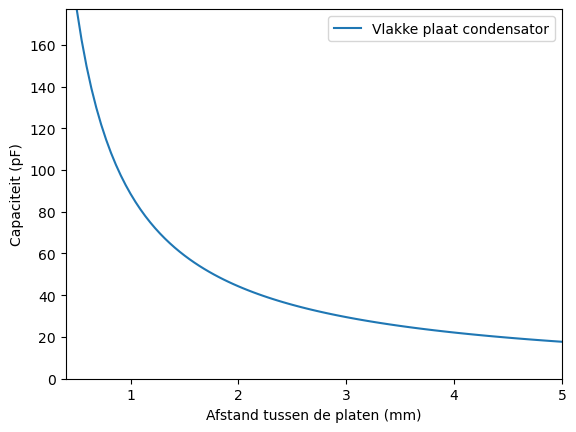

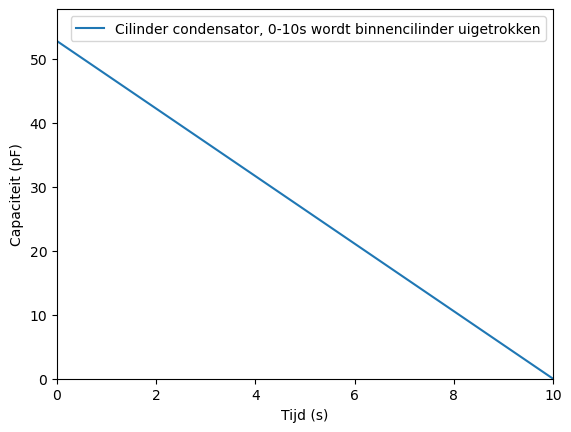

In [25]:
#opdracht 1
A = 0.1*0.1 #m2
d = np.linspace(0.5e-3, 5e-3,100) #m, array voor op de x-as
C = vlakkeplaat(A, d, epsilon0) #F, berekende capaciteit array voor op de y-as

#grafiek
plt.figure()
plt.xlabel('Afstand tussen de platen (mm)')
plt.ylabel('Capaciteit (pF)')
plt.xlim(0.4, 5)
plt.ylim(0,max(C*10**12))
plt.plot(d*1e3,C*10**12, label='Vlakke plaat condensator')
plt.legend()
plt.show()


#opdracht 2
a = 9e-3 * 0.5 #straal binnenste cilinder (m)
b = 10e-3 * 0.5 #straal buitenste cilinder (m)
L = np.linspace(0.1,0,100) #m, wanneer de cilinder er langzaam uitgetrokken wordt
#10 cm in 10 seconde, dus elke s 1 cm
t = np.linspace(0,10,100) #s
C = cilinder(L, a, b, epsilon0) #F

plt.figure()
plt.xlabel('Tijd (s)')
plt.ylabel('Capaciteit (pF)')
plt.xlim(0,10)
plt.ylim(0,max(C*10**12)+5)
plt.plot(t,C*10**12, label='Cilinder condensator, 0-10s wordt binnencilinder uigetrokken')
plt.legend()
plt.show()



## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [26]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*